
**I) TÍNH TOÁN MA TRẬN TERM-DOCUMENT**

***1) TIỀN XỬ LÝ DỮ LIỆU***
- Tách câu với sent_tokenize
- Tách từ tiếng Anh với word_tokenize
- Lọc bỏ các từ stopword với danh sách stopword tiếng Anh
- Chuyển về dạng từ gốc với Porter stemmer

In [36]:
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [37]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [38]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [39]:
stoplist = stopwords.words("english")
print(stoplist)
print(len(stoplist))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

VÍ DỤ MINH HỌA VIỆC TIỀN XỬ LÝ

Cho tập văn bản Docs={d1, d2, d3, d4, d5}

d1 = Romeo and Juliet

d2 = Juliet: Oh happy dagger

d3 = Romeo died by dagger

d4 = "live free or die" is from New-Hampshire

d5 = He is from New-Hampshire

Xử lý câu truy vấn q = die dagger

In [40]:
Docs = ['Romeo and Juliet', "Juliet: Oh happy dagger", "Romeo died by dagger", '"live free or die" is from New-Hampshire', "He is from New-Hampshire"]
q = "die dagger"

In [41]:
puncts = ['.', ',', ':', '`', '"', "'", '!', '?', "``", "''"]
stoplist.append('oh')
ps = PorterStemmer()

In [42]:
DD = []
for i in range(len(Docs)):
  sentences = sent_tokenize(Docs[i])
  terms = []
  for j in range(len(sentences)):
    toks = word_tokenize(sentences[j])
    for tok in toks:
      tok = tok.lower()
      if tok.isdigit():
        continue
      if tok.isnumeric():
        continue
      if tok in puncts:
        continue
      if tok in stoplist:
        continue
      terms.append(ps.stem(tok))
  DD.append(terms)
print(DD)

[['romeo', 'juliet'], ['juliet', 'happi', 'dagger'], ['romeo', 'die', 'dagger'], ['live', 'free', 'die', 'new-hampshir'], ['new-hampshir']]


***2) TẠO MA TRẬN TERM-DOCUMENT***

- Chọn term, mỗi term là một dòng trong ma trận
- Mỗi tài liệu là một cột trong ma trận
- Giá trị mỗi ô tùy thuộc vào phương pháp tính toán. Chẳng hạn, giá trị mỗi ô có thể là tần số của term trong tài liệu tương ứng.

***VÍ DỤ TẠO MA TRẬN TERM-DOCUMENT***

Các term được xác định là những từ còn lại sau khi tiền xử lý tập tài liệu D.

Giá trị mỗi ô là tần số của term trong tài liệu tương ứng.

In [43]:
from nltk.probability import FreqDist
allterms = []
for itm in DD:
  allterms.extend(itm)
fd = FreqDist(allterms)
for key in fd.keys():
  print(key, fd[key])

romeo 2
juliet 2
happi 1
dagger 2
die 2
live 1
free 1
new-hampshir 2


In [44]:
termdoc = []
keys = list(fd.keys())
for i in range(len(keys)):
  r = [0] * len(DD)
  termdoc.append(r)
for i in range(len(DD)):
  for w in DD[i]:
    for j in range(len(keys)):
      if keys[j] == w:
        termdoc[j][i] += 1
        break
print(termdoc)

[[1, 0, 1, 0, 0], [1, 1, 0, 0, 0], [0, 1, 0, 0, 0], [0, 1, 1, 0, 0], [0, 0, 1, 1, 0], [0, 0, 0, 1, 0], [0, 0, 0, 1, 0], [0, 0, 0, 1, 1]]


**II) PHÂN TÍCH NGỮ NGHĨA TIỀM ẨN**

***1) TÁCH MA TRẬN VỚI SINGULAR VALUE DECOMPOSITION***

- Tạo ma trận term-document A
- Sử dụng hàm svd trong package numpy.linalg để tách ma trận A thành các ma trận S, Z và UT thỏa A = S.Z.UT.


In [45]:
import numpy as np
from numpy.linalg import svd, norm
from numpy import dot


In [46]:
S, Z, UT = svd(termdoc)
print(S)
print(Z)
print(UT)

[[-3.96152775e-01  2.80057367e-01  5.71171321e-01  4.49684978e-01
   1.01838799e-01  3.14548241e-01  3.14548241e-01  1.67108527e-01]
 [-3.14268061e-01  4.49532136e-01 -4.10590545e-01  5.13018237e-01
  -2.03906072e-01 -3.14548241e-01 -3.14548241e-01 -1.67108527e-01]
 [-1.78239520e-01  2.68991539e-01 -4.97320521e-01 -2.56997782e-01
  -4.30523318e-02  2.26566432e-01  2.26566432e-01  6.91361313e-01]
 [-4.38363755e-01  3.68508309e-01 -1.28791752e-02 -5.77328823e-01
   2.19640207e-01  8.79818089e-02  8.79818089e-02 -5.24252786e-01]
 [-5.24004819e-01 -2.46404656e-01  3.38652269e-01 -2.72846164e-01
  -1.54791485e-01 -4.02530050e-01 -4.02530050e-01  3.57144258e-01]
 [-2.63880584e-01 -3.45921426e-01 -1.45789077e-01  4.74848765e-02
  -4.17484024e-01  7.01265025e-01 -2.98734975e-01 -1.78572129e-01]
 [-2.63880584e-01 -3.45921426e-01 -1.45789077e-01  4.74848765e-02
  -4.17484024e-01 -2.98734975e-01  7.01265025e-01 -1.78572129e-01]
 [-3.26373224e-01 -4.59668780e-01 -3.17002971e-01  2.37243804e-01
   

In [47]:
S2 = S[:,:2]
Z2 = np.diag(Z[:2])
UT2 = UT[:2,:]
print(S2)
print(Z2)
print(UT2)

[[-0.39615277  0.28005737]
 [-0.31426806  0.44953214]
 [-0.17823952  0.26899154]
 [-0.43836375  0.36850831]
 [-0.52400482 -0.24640466]
 [-0.26388058 -0.34592143]
 [-0.26388058 -0.34592143]
 [-0.32637322 -0.45966878]]
[[2.28529793 0.        ]
 [0.         2.01025824]]
[[-0.31086574 -0.40733041 -0.59446137 -0.60304575 -0.1428143 ]
 [ 0.36293322  0.54074246  0.20005441 -0.6953914  -0.22866156]]


***2) BIỂU DIỄN TERM VÀ DOCUMENT THEO KHÔNG GIAN MỚI***

- Tập vector term là K = S.Z
- Tập vector document là D = Z.UT


In [77]:
K = S2.dot(Z2)
D = Z2.dot(UT2)

print(K)
print(D)

[[-0.90532712  0.56298763]
 [-0.71819615  0.90367568]
 [-0.40733041  0.54074246]
 [-1.00179178  0.74079687]
 [-1.19750713 -0.49533699]
 [-0.60304575 -0.6953914 ]
 [-0.60304575 -0.6953914 ]
 [-0.74586005 -0.92405295]]
[[-0.71042084 -0.93087134 -1.35852135 -1.37813921 -0.32637322]
 [ 0.7295895   1.08703198  0.40216102 -1.39791629 -0.45966878]]


In [78]:
Xk = K[:,:1]
Xk = Xk.transpose()
Xk = Xk.squeeze()
Yk = K[:,1:]
Yk = Yk.transpose()
Yk = Yk.squeeze()
print(keys)
print(Xk)
print(Yk)

['romeo', 'juliet', 'happi', 'dagger', 'die', 'live', 'free', 'new-hampshir']
[-0.90532712 -0.71819615 -0.40733041 -1.00179178 -1.19750713 -0.60304575
 -0.60304575 -0.74586005]
[ 0.56298763  0.90367568  0.54074246  0.74079687 -0.49533699 -0.6953914
 -0.6953914  -0.92405295]


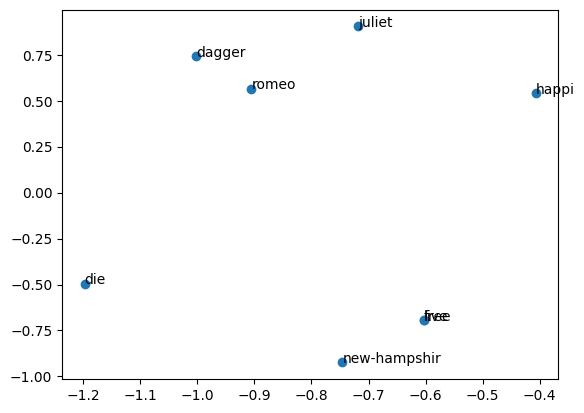

In [80]:
from nltk.util import in_idle
from io import IncrementalNewlineDecoder
%matplotlib notebook
import matplotlib.pyplot as plt
%matplotlib inline
fig = plt.figure(1)
ax = fig.add_subplot(111)
ax.plot(Xk, Yk, 'o')
for i in range(len(keys)):
  ax.annotate(keys[i], xy=(Xk[i], Yk[i]), textcoords='data')
plt.show()

In [81]:
Vq = (K[3] + K[4]) / 2
print(K[3])
print(K[4])
print(Vq)

[-1.00179178  0.74079687]
[-1.19750713 -0.49533699]
[-1.09964945  0.12272994]


***3) TÍNH TOÁN ĐỘ TƯƠNG ĐỒNG GIỮA TÀI LIỆU VÀ TRUY VẤN***

- Tính vector truy vấn là trung bình của các vector term có trong truy vấn.

- Tính khoảng cách cosine từ vector truy vấn đến từng vector tài liệu.

- Xếp tài liệu theo thứ tự giảm dần của khoảng cách cosine.


In [82]:
D = D.transpose()
scores = []
i = 1
for d in D:
  scores.append((i, (dot(Vq, d)/norm(Vq)/norm(d)).item()))
  i += 1

In [83]:
scores = sorted(scores, key=lambda x: x[1], reverse=True)
print(scores)

[(3, 0.9844359912676066), (1, 0.7727964887537563), (2, 0.7306768205359736), (4, 0.6187306127613204), (5, 0.48491831850738076)]


***4) TÍNH TOÁN ĐỘ TƯƠNG ĐỒNG GIỮA TÀI LIỆU VÀ TRUY VẤN***

- Biến đổi tập văn bản đã được tiền xử lý thành ma trận Term-Document bằng CountVectorizer hoặc TfidfVectorizer,
- Dùng lớp TruncatedSVD để tính toán và lưu trữ các ma trận. Kết quả tính toán của lớp này là các vector của văn bản.
- Tính độ đo cosine giữa ma trận tài liệu và vector của câu truy vấn.

In [84]:
DDoc = []
for d in DD:
  DDoc.append(" ".join(d))

In [85]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = CountVectorizer(stop_words='english')
term_doc = vectorizer.fit_transform(DDoc)

n_components = 2  # Dimensionality reduction
svd = TruncatedSVD(n_components=n_components, random_state=36)
lsi = svd.fit_transform(term_doc)

print(lsi)

vq = vectorizer.transform([q])
vq = svd.transform(vq)

i = 1
scores = []
for s in cosine_similarity(vq, lsi)[0]:
  scores.append((i, s.item()))
  i += 1

scores = sorted(scores, key=lambda x: x[1], reverse=True)
print(scores)

[[ 0.26578572  0.97086787]
 [ 0.3274026   1.35073974]
 [ 0.81906981  1.13058227]
 [ 2.12081705 -0.56267347]
 [ 0.98333442 -0.44031495]]
[(3, 0.9899807008157224), (1, 0.8769003219492789), (2, 0.8623852738609027), (4, 0.48756617735316693), (5, 0.3406714911980968)]


**BÀI TẬP**

- Xử lý các câu truy vấn cho bộ tài liệu Cranfield theo LSI

- So sánh với kết quả xử lý câu truy vấn của Whoose khi sử dụng công thức xếp hạng TF_IDF và BM25 theo độ đo MAP nội suy (MAP 11 điểm)